In [238]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from typing import TypedDict
from langchain_core.messages import HumanMessage,SystemMessage
from dotenv import load_dotenv
import os

load_dotenv()

True

In [239]:
# llm = HuggingFaceEndpoint(
#     repo_id="meta-llama/Llama-3.3-70B-Instruct:fireworks-ai",
#     task="text-generation",
#     timeout=300
# )

# chat = ChatHuggingFace(llm=llm)





# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(
#     base_url="http://localhost:8080/",
#     api_key="sk-no-key",   # required but ignored
#     model="qwen",          # name doesn't matter much here
#     temperature=0
# )

#chat=llm


from langchain_cerebras import ChatCerebras
llm = ChatCerebras(
    model="qwen-3-235b-a22b-instruct-2507",
    api_key=os.getenv("CEREBRAS_API_KEY"),
    temperature=0.7,
    max_tokens=800 
)

chat=llm

In [240]:
# result=llm.invoke("china south china sea philippines response script in hindi in 60 seconds with suspenseful tone and prashant dhawan style")

In [241]:
# result


In [242]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [243]:
#state
from typing import Literal
class YTScriptState(TypedDict):
    topic:str
    script:str
    evaluation:Literal["approved","needs_improvement"]
    feedback:str
    iteration:int
    max_iterations:int
    score:int
    search_results: str
    
    
    

In [244]:
from pydantic import BaseModel, Field

class script_evaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result of the script.")
    feedback: str = Field(..., description="feedback for the script that will improve it.")
    score: int=Field(..., description="A score from 1-50 indicating the quality of the script, where 1 is the lowest and 50 is the hightest.")

In [245]:
def generate_script(state:YTScriptState):
    print("Currently in generation phase")
    messages=[
        SystemMessage(content="n expert Geopolitical Analyst and a top-tier Indian Defense/Geopolitics YouTuber (specifically emulating the style of Prashant Dhawan from World Affairs)."),
        HumanMessage(content=f"""Your task is to write a highly engaging YouTube Shorts script (approx. 180-220 words, for a 60-second video) based on the topic provided below.
**REAL-TIME DATA (USE THIS STRICTLY For Recent Developments):** : {state['search_results']}
**CRITICAL STYLE & TONE INSTRUCTIONS:**
1. **Language:** Write entirely in the Devanagari script (Hindi), but use heavy "Hinglish". Do NOT use pure or complex Hindi words. Freely use English words transliterated in Devanagari (e.g., रिसेंटली, डिस्ट्रॉय, स्ट्रेटेजिक एलआई, इवेंचुअली, जियोपॉलिटिक्स, एम्बरेसमेंट, डोमिनेट).
2. **Tone:** Authoritative, highly analytical, urgent, and dramatic yet strictly grounded in facts and numbers. 
3. **Delivery:** Speak directly to the audience using conversational phrases like "मैं आपको बता दूं", "अब आप मुझे बताइए", "यह अजीब बात देखिए", "रिसेंटली".
4.  Prefer recent developments
**SCRIPT STRUCTURE (Strictly follow this 5-part flow):**

* **Part 1: The Hook (0-5 sec):** Start abruptly with a massive breaking news update, a shocking statistic, or a strong quote from a global leader. Catch the viewer's attention instantly.
* **Part 2: Context & Evidence (5-25 sec):** Explain the core conflict or news. Mention specific international media reports, military hardware (e.g., F-16, aircraft carriers), or exact financial numbers ($ Billions). If a leader made a statement, write their quote in English (Roman script) and then quickly explain its impact in Hindi.
* **Part 3: Comparative Analysis (25-40 sec):** Make the geopolitics easy to understand by comparing things. (e.g., Compare the defense budgets of the two countries involved, compare their military strength, or compare the current situation with a historical event).
* **Part 4: The Indian/Global Ripple Effect (40-55 sec):** Explain the broader consequence. How does this impact India (oil prices, defense readiness, foreign policy)? OR explain how a third unexpected country (like Russia or China) is secretly profiting or losing from this conflict.
* **Part 5: Outro & CTA (55-60 sec):** End with a suspenseful prediction about what might happen next (e.g., "यह एक जनरेशनल वॉर हो सकती है" or "यह देखना दिलचस्प होगा"). Then, close EXACTLY with this specific Call to Action: "अगर आप इसी तरीके से Jio पॉलिटिक्स पर अपडेट चाहते हैं, तो सब्सक्राइब करिए इस चैनल को।"

**TOPIC:** {state['topic']}
                     """)
    ]
    
    generated_script=chat.invoke(messages)
    
    return {"script":generated_script.content ,"iteration":0}

In [246]:
def evaluate_script(state:YTScriptState):
    evaluation_model=chat.with_structured_output(script_evaluation,method="json_schema")
    
    messages=[
        SystemMessage(content="""You are an Expert Content Strategist and Geopolitics Script Auditor. Your task is to rigorously evaluate a provided YouTube Shorts script to ensure it perfectly matches the exact style, tone, and pacing of "Prashant Dhawan"sir """),
        HumanMessage(content=f"""
                     Evaluate this script strictly. Score 1-10 per category.
    **CRITERIA:**
    1. **Language:** Must use Devanagari. Penalize formal Hindi (e.g., 'विनाश'). Reward English words in Devanagari (e.g., 'डिस्ट्रॉय', 'इम्पैक्ट').
    2. **Persona:** Use signature phrases ('मैं आपको बता दूं', 'अजीब बात देखिए'). Tone must be authoritative, not robotic.
    3. **Data/Quotes:** Require specific numbers ($ Billions, weapon names) and Roman-script English quotes followed by Hindi explanation.
    4. **Structure:** - 0-5s: Sharp Hook.
       - 5-25s: Context.
       - 25-40s: Data Comparison.
       - 40-55s: Impact on India/Global ripple.
    5. **CTA:** Must end EXACTLY: "अगर आप इसी तरीके से Jio पॉलिटिक्स पर अपडेट चाहते हैं, तो सब्सक्राइब करिए इस चैनल को।"

    **INPUT:**
    Topic: {state['topic']}
    Script: {state['script']}

    **OUTPUT REQUIREMENTS:**
    - Parameter Scores + 1-sentence justification.
    - Total Score (Fail <40, Good 40-45, Excellent >45).
    - Harsh Feedback: Rewrite weak lines into Dhawan's signature style.""")
    ]
    response=evaluation_model.invoke(messages)
    #return {"evaluation":response["evaluation"], "feedback":response["feedback"],"score":response["score"]}
    
    eval_result = "needs_improvement"
    eval_feedback = "The model failed to provide structured feedback. Retrying."
    eval_score = 0
    
    print("Currently in evaluation phase")
    if isinstance(response, dict):
        eval_result = response.get("evaluation") or eval_result
        eval_feedback = response.get("feedback") or eval_feedback
        eval_score = response.get("score") or eval_score
    elif response: # If it successfully returned the Pydantic object
        eval_result = getattr(response, "evaluation", eval_result)
        eval_feedback = getattr(response, "feedback", eval_feedback)
        eval_score = getattr(response, "score", eval_score)

    return {
        "evaluation": eval_result, 
        "feedback": eval_feedback,
        "score": eval_score
    }

In [247]:
def improvise_script(state:YTScriptState):
    print("Currently in improvization phase")
    message=[
        SystemMessage(content=f""" You are an elite YouTube Shorts script editor specializing in high-retention geopolitics content (Prashant Dhawan style).

        Your job is NOT to rewrite blindly.
        Your job is to surgically IMPROVE the script using the evaluator’s feedback.

        You must preserve:
        - Core topic
        - Structure
        - Flow

        You must FIX:
        - Language issues
        - Weak tone
        - Missing data
        - Structural gaps
        - CTA mistakes

        Think like a performance optimizer, not a writer."""),
        HumanMessage(content=f""" 
                     You are given:

         1. ORIGINAL SCRIPT
         2. DETAILED EVALUATION FEEDBACK

         Your task is to produce an IMPROVED VERSION of the script.

         ---

         ### 🔧 STRICT INSTRUCTIONS:

         1. **Do NOT change the topic or core narrative**
         2. **Do NOT reduce intensity — increase it if needed**
         3. Fix ALL issues mentioned in feedback:
            - Replace weak vocabulary with Hinglish (Devanagari)
            - Add missing numbers / stats if required
            - Insert comparison if missing
            - Improve hook if weak
            - Strengthen ending prediction
            - Ensure CTA is EXACT

         4. **Language Rule (CRITICAL):**
            - Fully Devanagari script
            - Heavy Hinglish (रिसेंटली, डिस्ट्रॉय, स्ट्रेटेजिक, कॉन्फ्लिक्ट)
            - Avoid pure Hindi words

         5. **Tone Fix:**
            - More assertive
            - More dramatic
            - Add phrases like:
            - "मैं आपको बता दूं"
            - "अब आप मुझे बताइए"
            - "अजीब बात देखिए"

         6. **Data Upgrade Rule:**
            - If feedback says "lack of numbers" → ADD numbers
            - If vague → make specific

         7. **Structure Enforcement:**
            Ensure this flow exists clearly:
            - Hook
            - Context
            - Comparison
            - Global/India impact
            - Prediction + CTA

         8. **Do NOT explain anything**
            - Only output final improved script

         ---

         ### INPUTS:

         **TOPIC:**
         {state['topic']}

         **ORIGINAL SCRIPT:**
         {state['script']}

         **EVALUATION FEEDBACK:**
         {state['feedback']}

         ---

         ### OUTPUT:
         Only return the improved script (ready to record).
                              """)]
    response=chat.invoke(message)
    return { 'script':response.content , 'iteration':state['iteration']+1}

In [248]:
def check_evaluation(state:YTScriptState):
    print("Currently in conditional evaluation")
    if state['iteration']>=state['max_iterations']:
        return "approved"
    
    if state['evaluation']=="approved" or state['score']>=45:
        return "approved" 
    return "needs_improvement"

In [249]:
def web_search(state: YTScriptState):
    print("Currently in web search phase")

    raw_results = search_tool.run(state["topic"])

    return {
        "search_results": raw_results
    }

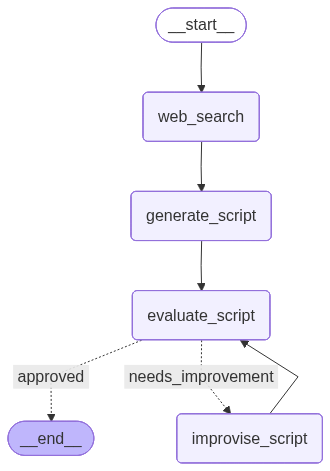

In [250]:
graph=StateGraph(YTScriptState)

graph.add_node('generate_script',generate_script)
graph.add_node('evaluate_script',evaluate_script)
graph.add_node('improvise_script',improvise_script)
graph.add_node('web_search', web_search)

graph.add_edge(START, 'web_search')
graph.add_edge('web_search', 'generate_script')
graph.add_edge('generate_script','evaluate_script')
graph.add_conditional_edges('evaluate_script',check_evaluation,{'approved':END,'needs_improvement':'improvise_script'})
graph.add_edge('improvise_script','evaluate_script')



workflow=graph.compile()

workflow

In [259]:
initial_state = {
    "topic": "Rajpal Yadav controversy",
    "max_iterations": 10,
    "iteration": 0,
    "score": 0,             # Initialize to 0
    "evaluation": "needs_improvement" # Initialize
}

result = workflow.invoke(initial_state)

Currently in web search phase
Currently in generation phase


RateLimitError: Error code: 429 - {'message': "We're experiencing high traffic right now! Please try again soon.", 'type': 'too_many_requests_error', 'param': 'queue', 'code': 'queue_exceeded'}

In [254]:
result

{'topic': 'Rajpal Yadav controversy',
 'script': 'रिसेंटली एक बड़ा अपडेट – 6 घंटे पहले, रजपाल यादव ने कोर्ट में सरेंडर कर दिया। कारण? 2.43 करोड़ का चेक बाउंस! मैं आपको बता दूं – यह सिर्फ चेक बाउंस नहीं, बल्कि इमेज डिस्ट्रॉय हो गई है!\n\nअजीब बात देखिए: चेतक स्क्रीन अवॉर्ड्स में होस्ट सौरभ द्विवेदी ने जोक मारा – “रजपाल भाई, चेक तो बाउंस हो गया, लेकिन परफॉरमेंस नहीं बाउंस हुई!” वीडियो वायरल – 22 घंटे में 8.7 लाख व्यूज, 3,842 अपवोट्स, 12,000+ शेयर्स। मैं आपको बता दूं, यह सिर्फ कॉमेडी नहीं – यह सोशल इंस्टीगेशन है। “Accountability? Ha!” – ट्विटर यूजर @FilmBazaar ने लिखा, जिस पर 7.4K रिप्लाईज आ चुके हैं।\n\nतुलना करिए: विवेक ओबेरॉय के साथ 1.8 करोड़ का पेमेंट विवाद, अब रजपाल – 2.43 करोड़। दोनों केसेज में कॉमन थिंग? फैंस की लॉयल्टी अभी भी बरकरार। लेकिन 2024 में डिजिटल जजमेंट का दौर शुरू हो चुका है। ट्विटर, इंस्टाग्राम, रेड्डिट – हर प्लेटफॉर्म पर डिबेट: “क्या एक्टर्स को फाइनेंशियल एकाउंटेबिलिटी के लिए भी जवाब देन',
 'evaluation': 'needs_improvement',
 'feedback': "Script has strong hook and use